# Football Tactical Momentum Analyzer — Exploratory Analysis

This notebook walks through the same pipeline as `src/main.py`, but interactively: load data, clean it, compute the Momentum Index, explore team/player ratings, and visualize a few charts inline.

In [1]:
import sys
from pathlib import Path

# Make src/ importable from the notebooks/ folder
SRC = Path.cwd().parent / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import pandas as pd
import matplotlib.pyplot as plt

from data_loader import load_raw_data
from cleaner import clean_events
from config import RAW_EVENTS_FILE

pd.set_option("display.max_columns", 30)

## 1. Load & clean data

In [2]:
raw = load_raw_data(RAW_EVENTS_FILE)
df = clean_events(raw)
print(f"{len(df):,} clean events across {df['match_id'].nunique()} matches")
df.head()

2026-07-03 12:13:03 | INFO     | momentum_analyzer.data_loader | Loading raw events from /home/claude/football-tactical-momentum-analyzer/data/raw/events.csv


2026-07-03 12:13:03 | INFO     | momentum_analyzer.data_loader | Loaded 4998 raw rows


2026-07-03 12:13:03 | INFO     | momentum_analyzer.cleaner | Cleaned events: 4998 -> 4998 rows (0 dropped)


4,998 clean events across 6 matches


,event_id,match_id,home_team,away_team,team,opponent,player,position,shirt_number,minute,second,event_type,x,y,outcome,xg,match_seconds
0,1,1,Barau,Remo Stars,Remo Stars,Barau,Femi Osazuwa,LW,25,0,1,Pass,86.34,44.65,Complete,0.0,1
1,2,1,Barau,Remo Stars,Remo Stars,Barau,Femi Osazuwa,LW,25,0,7,Pass,79.13,75.36,Complete,0.0,7
2,3,1,Barau,Remo Stars,Barau,Remo Stars,Joseph Nnamdi,ST,27,0,9,Successful Dribble,57.88,46.27,Complete,0.0,9
3,4,1,Barau,Remo Stars,Remo Stars,Barau,Chukwuemeka Osazuwa,CAM,12,0,12,Corner,83.96,36.55,Complete,0.0,12
4,5,1,Barau,Remo Stars,Barau,Remo Stars,Tunde Osazuwa,CB,23,0,14,Turnover,54.39,80.00,Complete,0.0,14


## 2. Momentum Index for a single match

In [3]:
from momentum import compute_momentum_index, momentum_summary

match_id = int(df['match_id'].iloc[0])
teams = sorted(df[df['match_id'] == match_id]['team'].unique())
momentum_df = compute_momentum_index(df, match_id=match_id)
momentum_df.head()

2026-07-03 12:13:03 | INFO     | momentum_analyzer.momentum | Computed momentum index for match 1 over 91 minutes


,minute,Barau,Remo Stars,momentum_diff,leader
0,0,17.39,9.27,8.12,Barau
1,1,16.36,15.27,1.09,Barau
2,2,16.53,17.96,-1.43,Remo Stars
3,3,16.47,19.76,-3.29,Remo Stars
4,4,17.21,17.79,-0.58,Remo Stars


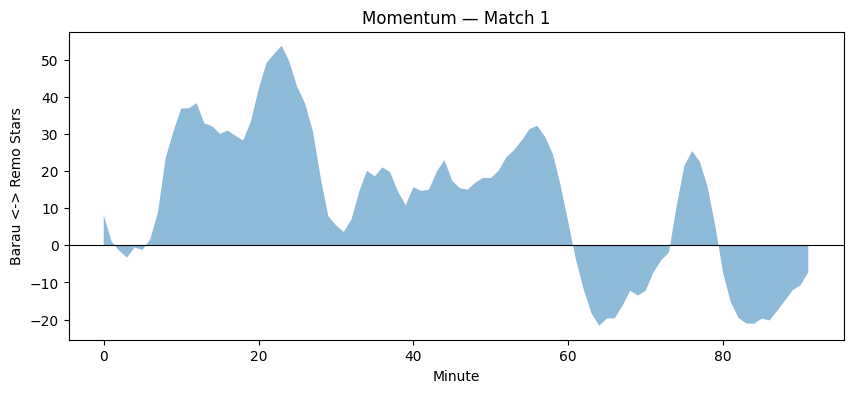

In [4]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.fill_between(momentum_df['minute'], momentum_df['momentum_diff'], 0, alpha=0.5)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('Minute'); ax.set_ylabel(f"{teams[0]} <-> {teams[1]}")
ax.set_title(f"Momentum — Match {match_id}")
plt.show()

if len(teams) == 2:
    momentum_summary(momentum_df, teams[0], teams[1])

## 3. Team & player analytics

In [5]:
from analysis import team_match_stats, team_ratings, performance_summary, correlation_matrix
from player_analysis import player_match_stats, player_rating, top_performers

stats = team_match_stats(df)
perf = performance_summary(stats)
perf

,team,matches,goals,xg,shots,shots_on_target,avg_possession_pct,avg_pass_accuracy_pct,fouls,yellow_cards,red_cards,goals_per_match,xg_per_match,shot_conversion_pct
0,Kano Pillars,1,0.0,11.86,39.0,11.0,51.3,82.7,25.0,4.0,0.0,0.0,11.86,0.0
1,Katsina United,1,2.0,11.24,36.0,13.0,49.0,87.0,27.0,6.0,1.0,2.0,11.24,5.6
2,Barau,1,0.0,11.04,37.0,15.0,52.1,84.3,15.0,3.0,0.0,0.0,11.04,0.0
3,Remo Stars,2,7.0,21.80,73.0,26.0,48.9,82.8,54.0,9.0,1.0,3.5,10.90,9.6
4,Enugu Rangers,1,1.0,10.78,35.0,10.0,50.1,81.9,26.0,6.0,0.0,1.0,10.78,2.9
5,Enyimba,1,3.0,9.95,33.0,10.0,49.1,79.8,31.0,5.0,0.0,3.0,9.95,9.1
6,Kwara United,2,1.0,17.81,62.0,22.0,48.6,84.0,43.0,8.0,1.0,0.5,8.91,1.6
7,Nasarawa United,1,1.0,8.74,30.0,10.0,50.9,82.2,17.0,2.0,1.0,1.0,8.74,3.3
8,Niger Tornadoes,1,2.0,8.37,30.0,6.0,53.7,81.6,28.0,6.0,0.0,2.0,8.37,6.7
9,Kun Khalifat,1,2.0,7.24,23.0,10.0,48.7,82.9,26.0,9.0,2.0,2.0,7.24,8.7


In [6]:
p_stats = player_match_stats(df)
p_ratings = player_rating(df)
top_performers(p_stats, p_ratings, n=10)

,match_id,player,rating,team,position,events,goals,shots,xg,passes,pass_accuracy_pct,dribbles,tackles,interceptions,fouls,yellow_cards,red_cards
0,1,Joseph Nnamdi,100.0,Barau,ST,32,0,3,0.73,13,76.9,6,5,2,1,1,0
1,2,Femi Ekong,100.0,Remo Stars,LB,28,0,5,1.55,16,81.2,1,2,3,0,0,0
2,4,Olamide Abubakar,100.0,Nasarawa United,CDM,34,0,6,1.84,17,70.6,2,4,1,0,0,0
3,3,Adewale Mustapha,100.0,Katsina United,ST,25,1,5,1.62,10,80.0,1,4,2,0,0,1
4,5,Femi Nwankwo,100.0,Kun Khalifat,CM,33,0,2,0.40,18,83.3,1,4,4,0,1,0
5,6,Chibuzor Onuoha,100.0,Niger Tornadoes,CAM,29,1,2,0.77,19,89.5,2,1,3,0,1,0
6,2,Tunde Etim,97.7,Remo Stars,RW,19,2,3,0.88,9,55.6,1,1,2,1,0,0
7,4,Joseph Balogun,96.9,Enyimba,RW,28,1,3,1.36,16,87.5,1,2,3,0,0,0
8,5,Emmanuel Lawal,96.7,Kano Pillars,CDM,28,0,5,1.81,12,91.7,2,2,1,2,0,0
9,4,Chidi Chukwu,95.8,Enyimba,CAM,32,1,4,1.20,16,75.0,3,2,1,3,0,0


## 4. Correlation heatmap

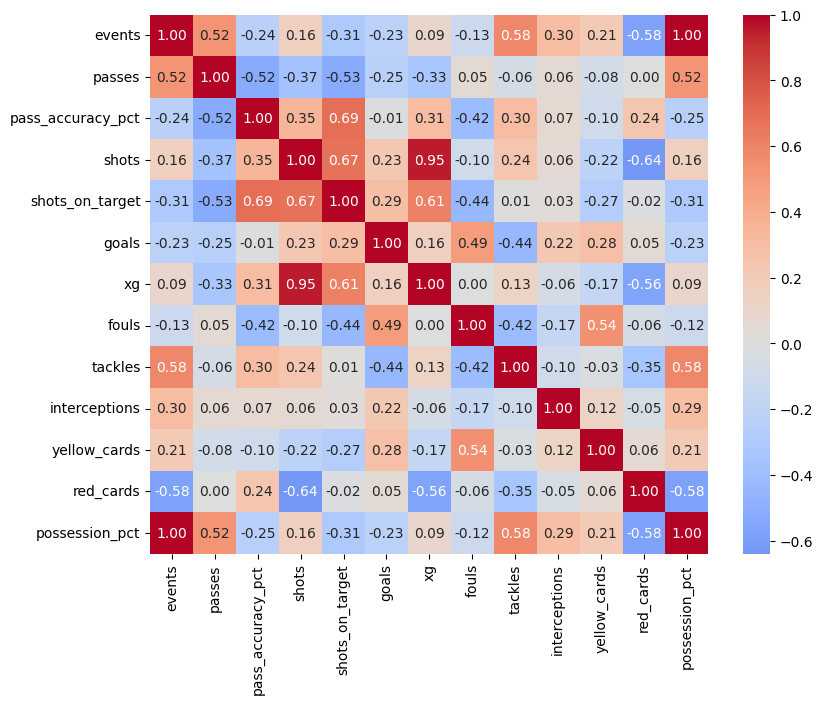

In [7]:
import seaborn as sns

corr = correlation_matrix(stats)
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
plt.show()

## Next steps

- Run `python ../src/main.py` from the repo root to regenerate the full PDF / Excel / HTML report bundle.
- Run `streamlit run ../src/dashboard.py` for the interactive dashboard.